# Crop Dataset — Regression Analysis
Multi Linear Regression + Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    classification_report, confusion_matrix, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('final_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (989, 14)


,Crop Name,District Name,Crop Year,Crop Season,Cultivation Area (Hectare),Production (Tonne),Yield (Tonne per Hectare),Cost of Cultivation per Hectare (INR),Revenue per Hectare (INR),Annual Rainfall (mm),Rainfall Category,Organic Phase Code,Organic Phase Label,Rainfall Category Code
0,Barley,Gangtok,1997,Rabi,500,500.0,1.00,5100,2700,3100,Normal,0,Conventional,1
1,Barley,Gangtok,1998,Rabi,340,270.0,0.79,5500,2144,2890,Normal,0,Conventional,1
2,Barley,Gangtok,1999,Rabi,340,500.0,1.47,5900,4118,3210,Normal,0,Conventional,1
3,Barley,Gangtok,2000,Rabi,340,390.0,1.15,6300,3326,2780,Deficient,0,Conventional,2
4,Barley,Gangtok,2001,Rabi,340,440.0,1.29,6780,4012,3080,Normal,0,Conventional,1


## 1. Basic EDA

In [2]:
print(df.dtypes)
print('\nNull values:\n', df.isnull().sum())
df.describe()

Crop Name                                    str
District Name                                str
Crop Year                                  int64
Crop Season                                  str
Cultivation Area (Hectare)                 int64
Production (Tonne)                       float64
Yield (Tonne per Hectare)                float64
Cost of Cultivation per Hectare (INR)      int64
Revenue per Hectare (INR)                  int64
Annual Rainfall (mm)                       int64
Rainfall Category                            str
Organic Phase Code                         int64
Organic Phase Label                          str
Rainfall Category Code                     int64
dtype: object

Null values:
 Crop Name                                0
District Name                            0
Crop Year                                0
Crop Season                              0
Cultivation Area (Hectare)               0
Production (Tonne)                       0
Yield (Tonne per Hectare)  

,Crop Year,Cultivation Area (Hectare),Production (Tonne),Yield (Tonne per Hectare),Cost of Cultivation per Hectare (INR),Revenue per Hectare (INR),Annual Rainfall (mm),Organic Phase Code,Rainfall Category Code
count,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000
mean,2009.577351,1949.515672,3064.543175,1.245834,22429.635996,19276.789687,2605.631951,1.050556,1.200202
std,7.520911,3170.703556,9079.219274,1.301613,14342.746399,20061.388699,358.571912,0.703859,0.467961
min,1997.000000,2.000000,2.000000,0.070000,5000.000000,551.000000,1810.000000,0.000000,0.000000
25%,2003.000000,343.000000,292.000000,0.870000,10200.000000,6377.000000,2320.000000,1.000000,1.000000
50%,2009.000000,923.000000,910.000000,0.980000,18000.000000,13388.000000,2620.000000,1.000000,1.000000
75%,2016.000000,1700.000000,1600.000000,1.360000,33000.000000,26305.000000,2840.000000,2.000000,1.000000
max,2022.000000,17280.000000,233145.000000,16.270000,58500.000000,233074.000000,3740.000000,2.000000,2.000000


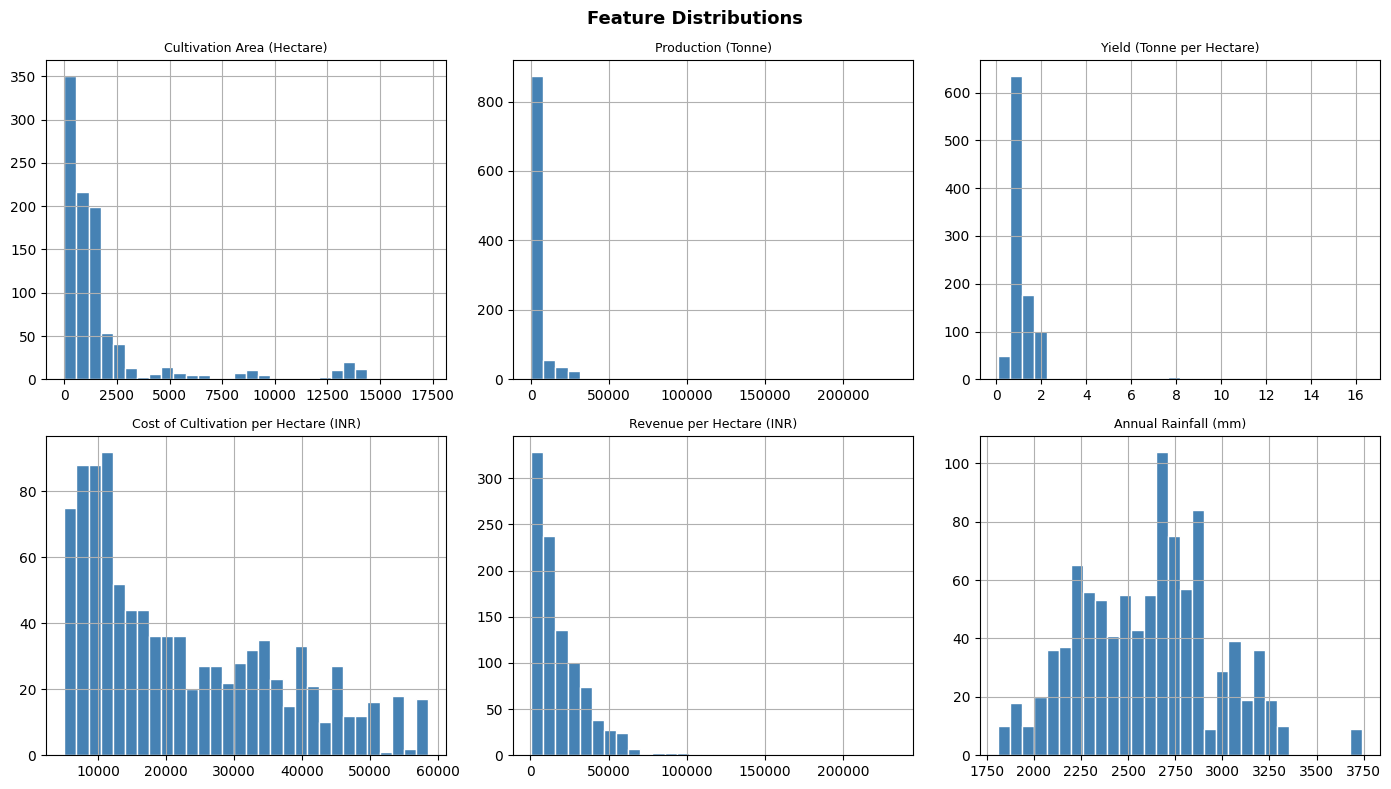

In [3]:
num_cols = ['Cultivation Area (Hectare)', 'Production (Tonne)', 'Yield (Tonne per Hectare)',
            'Cost of Cultivation per Hectare (INR)', 'Revenue per Hectare (INR)', 'Annual Rainfall (mm)']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=9)
plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

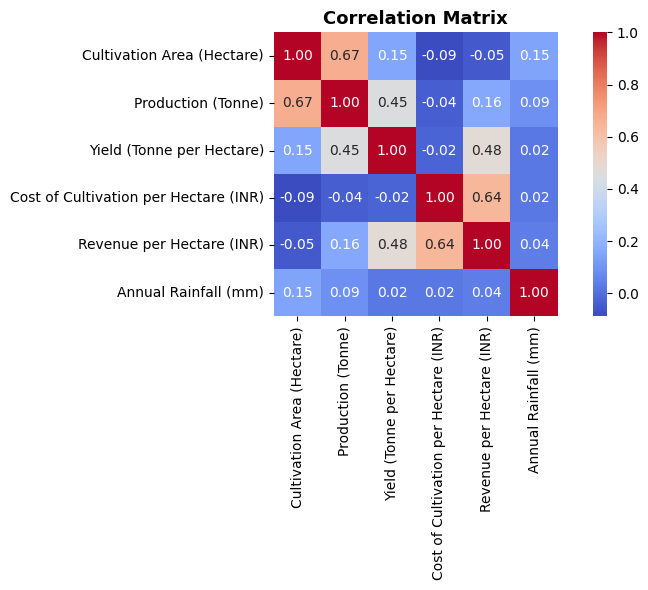

In [4]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Multiple Linear Regression
**Target:** `Revenue per Hectare (INR)`

In [5]:
features = ['Cultivation Area (Hectare)', 'Yield (Tonne per Hectare)',
            'Cost of Cultivation per Hectare (INR)', 'Annual Rainfall (mm)', 'Organic Phase Code']
target_reg = 'Revenue per Hectare (INR)'

df_clean = df[features + [target_reg]].dropna()
X_reg = df_clean[features]
y_reg = df_clean[target_reg]

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print('=== Multiple Linear Regression ===')
print(f'R² Score      : {r2_score(y_test, y_pred):.4f}')
print(f'RMSE          : {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}')
print(f'Intercept     : {lr.intercept_:,.2f}')
print('\nCoefficients:')
for feat, coef in zip(features, lr.coef_):
    print(f'  {feat:<45} {coef:>10.4f}')

=== Multiple Linear Regression ===
R² Score      : 0.6725
RMSE          : 10,142.57
Intercept     : -15,246.21

Coefficients:
  Cultivation Area (Hectare)                       -0.5970
  Yield (Tonne per Hectare)                      9089.9785
  Cost of Cultivation per Hectare (INR)             1.0827
  Annual Rainfall (mm)                              1.9258
  Organic Phase Code                            -4629.7140


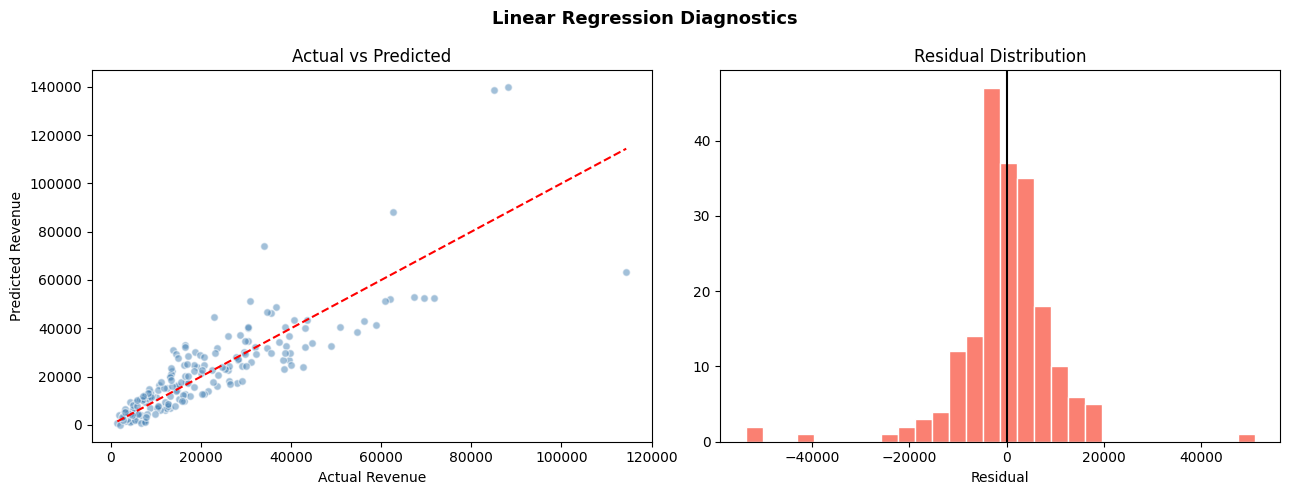

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=30)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
axes[0].set_xlabel('Actual Revenue')
axes[0].set_ylabel('Predicted Revenue')
axes[0].set_title('Actual vs Predicted')

# Residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=30, color='salmon', edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

plt.suptitle('Linear Regression Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

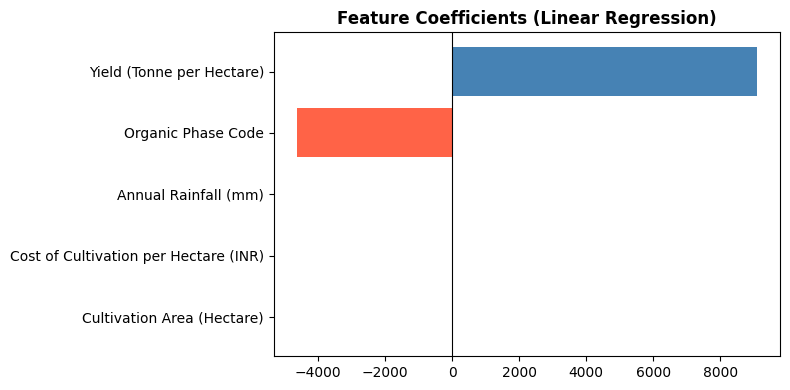

In [7]:
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index)

plt.figure(figsize=(8, 4))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients (Linear Regression)', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Logistic Regression
**Target:** `Rainfall Category Code` (0 = Excess, 1 = Normal, 2 = Deficient)

In [8]:
features_clf = ['Cultivation Area (Hectare)', 'Yield (Tonne per Hectare)',
                'Cost of Cultivation per Hectare (INR)', 'Revenue per Hectare (INR)',
                'Annual Rainfall (mm)', 'Organic Phase Code']
target_clf = 'Rainfall Category Code'

df_clf = df[features_clf + [target_clf]].dropna()
X_clf = df_clf[features_clf]
y_clf = df_clf[target_clf]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_c)
X_test_s  = scaler.transform(X_test_c)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train_c)
y_pred_c = log_reg.predict(X_test_s)

label_map = {0: 'Excess', 1: 'Normal', 2: 'Deficient'}
print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}\n')
print(classification_report(y_test_c, y_pred_c, target_names=[label_map[i] for i in sorted(label_map)]))

=== Logistic Regression ===
Accuracy: 0.7929

              precision    recall  f1-score   support

      Excess       1.00      0.83      0.91         6
      Normal       0.84      0.88      0.86       147
   Deficient       0.56      0.49      0.52        45

    accuracy                           0.79       198
   macro avg       0.80      0.74      0.77       198
weighted avg       0.79      0.79      0.79       198



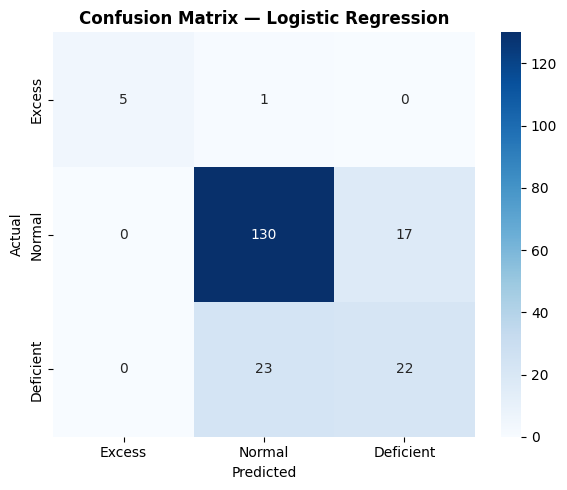

In [9]:
cm = confusion_matrix(y_test_c, y_pred_c)
labels = ['Excess', 'Normal', 'Deficient']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

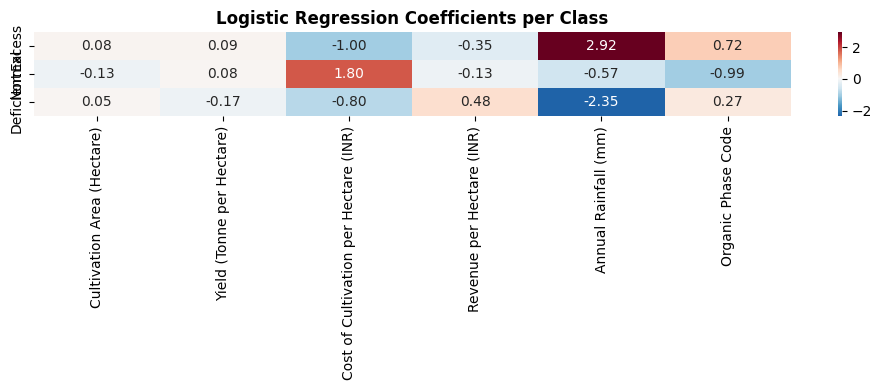

In [10]:
# Feature importance via logistic regression coefficients
coef_mat = pd.DataFrame(log_reg.coef_, columns=features_clf,
                        index=[label_map[c] for c in log_reg.classes_])

plt.figure(figsize=(10, 4))
sns.heatmap(coef_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Logistic Regression Coefficients per Class', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Key Insights

In [11]:
print('=== Summary ===')
print(f"Dataset size          : {len(df)} rows")
print(f"Crops                 : {df['Crop Name'].nunique()} unique crops")
print(f"Year range            : {df['Crop Year'].min()} – {df['Crop Year'].max()}")
print()
print(f"Linear Regression R²  : {r2_score(y_test, y_pred):.4f}")
print(f"Linear Regression RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f} INR")
print()
print(f"Logistic Regression Accuracy: {accuracy_score(y_test_c, y_pred_c)*100:.1f}%")
print()
print('Top revenue predictor :', features[np.argmax(np.abs(lr.coef_))])
avg_rev = int(df['Revenue per Hectare (INR)'].mean())
print(f'Avg Revenue/Hectare   : INR {avg_rev:,}')

=== Summary ===
Dataset size          : 989 rows
Crops                 : 13 unique crops
Year range            : 1997 – 2022

Linear Regression R²  : 0.6725
Linear Regression RMSE: 10,143 INR

Logistic Regression Accuracy: 79.3%

Top revenue predictor : Yield (Tonne per Hectare)
Avg Revenue/Hectare   : INR 19,276
